# Implement Workflow Patterns with LangGraph

Estimated time needed: **45** minutes

## Introduction

In this lab, you will implement three foundational workflow patterns with current LangGraph and LangChain APIs:

- **Prompt chaining**: pass the output of one LLM step into the next step.
- **Routing**: classify an input and route it to the correct specialized branch.
- **Parallelization**: run independent nodes at the same graph step and combine their outputs.

The examples use `StateGraph`, `START`, `END`, nodes that return partial state updates, and LangChain structured output via `with_structured_output(...)`.

## Table of Contents

1. [Setup](#Setup)
2. [Prompt Chaining](#Prompt-Chaining)
3. [Routing](#Routing)
4. [Parallelization](#Parallelization)
5. [Exercise: Multi-Service Routing System](#Exercise:-Multi-Service-Routing-System)

## Setup

Install dependencies from the repository environment rather than from inside the notebook. The examples expect `OPENAI_API_KEY` to be set in your environment.

In [1]:
from typing import Literal, TypedDict

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field
from langgraph.graph import START, END, StateGraph

load_dotenv()

c:\Users\A200239740\AppData\Local\miniconda3\envs\agents\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

In [2]:
llm = init_chat_model(model="gpt-5.4", model_provider="openai", temperature=0)

In [3]:
def show_graph(app):
    """Display a graph visualization when notebook rendering support is available."""
    try:
        from IPython.display import Image, display

        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as exc:
        print(f"Graph visualization skipped: {exc}")

## Prompt Chaining

Prompt chaining decomposes a task into a fixed sequence. Each node reads the shared state and returns only the fields it updates. LangGraph merges those partial updates into the graph state.

In [4]:
class ChainState(TypedDict):
    job_description: str
    resume_summary: str
    cover_letter: str


def generate_resume_summary(state: ChainState) -> dict:
    prompt = f"""
    You're a resume assistant. Read the job description and summarize the key
    qualifications and experience the ideal candidate should have.

    Job Description:
    {state["job_description"]}
    """
    response = llm.invoke(prompt)
    return {"resume_summary": response.content.strip()}


def generate_cover_letter(state: ChainState) -> dict:
    prompt = f"""
    You're a professional cover letter writer. Use the job description and
    resume summary to write a tailored cover letter.

    Job Description:
    {state["job_description"]}

    Resume Summary:
    {state["resume_summary"]}
    """
    response = llm.invoke(prompt)
    return {"cover_letter": response.content.strip()}

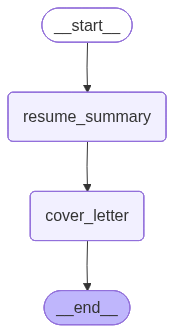

In [5]:
prompt_chain = StateGraph(ChainState)
prompt_chain.add_node("resume_summary", generate_resume_summary)
prompt_chain.add_node("cover_letter", generate_cover_letter)

prompt_chain.add_edge(START, "resume_summary")
prompt_chain.add_edge("resume_summary", "cover_letter")
prompt_chain.add_edge("cover_letter", END)

prompt_chain_app = prompt_chain.compile()
show_graph(prompt_chain_app)

In [6]:
chain_result = prompt_chain_app.invoke({
    "job_description": (
        "We are looking for a data scientist with experience in machine learning, "
        "NLP, Python, large datasets, and production model deployment."
    )
})

print(chain_result["resume_summary"])
print("\n--- COVER LETTER ---\n")
print(chain_result["cover_letter"])

Ideal candidate qualifications and experience:

- Strong experience as a **Data Scientist**
- Solid background in **machine learning**
- Experience with **natural language processing (NLP)**
- Proficiency in **Python**
- Ability to work with **large datasets**
- Experience with **deploying models into production**

In short, the ideal candidate should be a data scientist who can build ML/NLP solutions in Python, handle large-scale data, and successfully deploy models in real-world production environments.

--- COVER LETTER ---

Dear Hiring Manager,

I am excited to apply for the Data Scientist position. With strong experience as a Data Scientist and a solid background in machine learning, natural language processing, and Python, I am confident in my ability to contribute effectively to your team.

My experience includes developing machine learning models, working with NLP techniques to extract insights from text data, and building solutions that scale across large datasets. I am comfor

## Routing

Routing uses one node to classify the request and a conditional edge to choose the next branch. The router uses `with_structured_output(...)` so the routing decision is validated against a Pydantic schema.

In [7]:
class RouterState(TypedDict):
    user_input: str
    task_type: str
    output: str


class RouteDecision(BaseModel):
    task_type: Literal["summarize", "translate"] = Field(
        description="Route to summarize for summaries, or translate for French translation."
    )


router_llm = llm.with_structured_output(RouteDecision)


def router_node(state: RouterState) -> dict:
    decision = router_llm.invoke(
        f"Classify the user request as summarize or translate: {state['user_input']}"
    )
    return {"task_type": decision.task_type}


def route_task(state: RouterState) -> Literal["summarize", "translate"]:
    return state["task_type"]


def summarize_node(state: RouterState) -> dict:
    response = llm.invoke(f"Summarize this text:\n\n{state['user_input']}")
    return {"output": response.content.strip()}


def translate_node(state: RouterState) -> dict:
    response = llm.invoke(f"Translate this text to French:\n\n{state['user_input']}")
    return {"output": response.content.strip()}

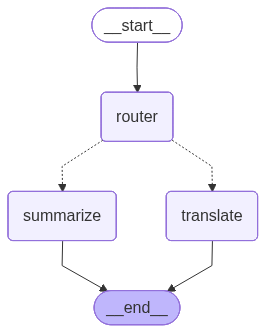

In [8]:
routing_graph = StateGraph(RouterState)
routing_graph.add_node("router", router_node)
routing_graph.add_node("summarize", summarize_node)
routing_graph.add_node("translate", translate_node)

routing_graph.add_edge(START, "router")
routing_graph.add_conditional_edges(
    "router",
    route_task,
    {
        "summarize": "summarize",
        "translate": "translate",
    },
)
routing_graph.add_edge("summarize", END)
routing_graph.add_edge("translate", END)

routing_app = routing_graph.compile()
show_graph(routing_app)

In [9]:
for user_input in [
    "Can you translate this sentence: I love programming?",
    "Can you summarize this sentence: I love programming so much that it is all I want to do?",
]:
    result = routing_app.invoke({"user_input": user_input})
    print(f"Input: {user_input}")
    print(f"Route: {result['task_type']}")
    print(f"Output: {result['output']}\n")

Input: Can you translate this sentence: I love programming?
Route: translate
Output: Pouvez-vous traduire cette phrase : J’aime programmer ?

Input: Can you summarize this sentence: I love programming so much that it is all I want to do?
Route: summarize
Output: The speaker is extremely passionate about programming and wants to do it above everything else.



## Parallelization

Parallelization starts multiple independent nodes from `START`. The aggregator waits for all translation nodes because `add_edge([...], "aggregator")` creates a fan-in edge from multiple start nodes to one destination.

In [10]:
class TranslationState(TypedDict):
    text: str
    french: str
    spanish: str
    japanese: str
    combined_output: str


def translate_french(state: TranslationState) -> dict:
    response = llm.invoke(f"Translate to French:\n\n{state['text']}")
    return {"french": response.content.strip()}


def translate_spanish(state: TranslationState) -> dict:
    response = llm.invoke(f"Translate to Spanish:\n\n{state['text']}")
    return {"spanish": response.content.strip()}


def translate_japanese(state: TranslationState) -> dict:
    response = llm.invoke(f"Translate to Japanese:\n\n{state['text']}")
    return {"japanese": response.content.strip()}


def aggregate_translations(state: TranslationState) -> dict:
    combined = (
        f"Original Text: {state['text']}\n\n"
        f"French: {state['french']}\n\n"
        f"Spanish: {state['spanish']}\n\n"
        f"Japanese: {state['japanese']}"
    )
    return {"combined_output": combined}

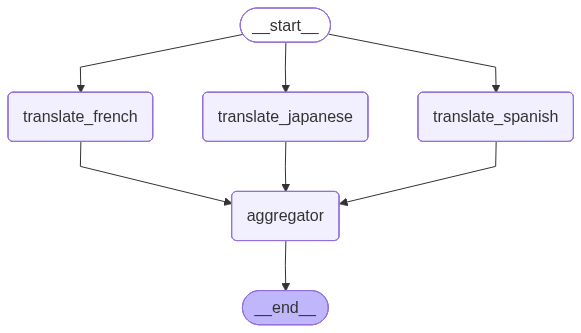

In [11]:
parallel_graph = StateGraph(TranslationState)
parallel_graph.add_node("translate_french", translate_french)
parallel_graph.add_node("translate_spanish", translate_spanish)
parallel_graph.add_node("translate_japanese", translate_japanese)
parallel_graph.add_node("aggregator", aggregate_translations)

parallel_graph.add_edge(START, "translate_french")
parallel_graph.add_edge(START, "translate_spanish")
parallel_graph.add_edge(START, "translate_japanese")
parallel_graph.add_edge(
    ["translate_french", "translate_spanish", "translate_japanese"],
    "aggregator",
)
parallel_graph.add_edge("aggregator", END)

parallel_app = parallel_graph.compile()
show_graph(parallel_app)

In [12]:
parallel_result = parallel_app.invoke({
    "text": "Good morning! I hope you have a wonderful day."
})

print(parallel_result["combined_output"])

Original Text: Good morning! I hope you have a wonderful day.

French: Bonjour ! J’espère que vous passerez une merveilleuse journée.

Spanish: ¡Buenos días! Espero que tengas un día maravilloso.

Japanese: おはようございます！素晴らしい一日になりますように。


## Exercise: Multi-Service Routing System

Build a router that classifies user requests into one of four service branches:

- `ride_hailing_call`
- `restaurant_order`
- `groceries`
- `default_handler`

The exercises below are completed using the current LangGraph/LangChain API style: structured output, `START`, `END`, conditional edges, and partial state updates.

### Completed Exercise 1: State Management and Router Schema

This solution defines the shared state, the allowed route labels, the Pydantic structured-output schema, the router model, and the route-selection function.

In [13]:
class ServiceRouterState(TypedDict):
    user_input: str
    task_type: str
    output: str


ServiceRoute = Literal[
    "ride_hailing_call",
    "restaurant_order",
    "groceries",
    "default_handler",
]


class ServiceRouteDecision(BaseModel):
    task_type: ServiceRoute = Field(
        description="Classify the request into the best matching service branch."
    )


service_router_llm = llm.with_structured_output(ServiceRouteDecision)


def service_router_node(state: ServiceRouterState) -> dict:
    decision = service_router_llm.invoke(
        "Classify this request as ride_hailing_call, restaurant_order, "
        f"groceries, or default_handler:\n\n{state['user_input']}"
    )
    return {"task_type": decision.task_type}


def route_service(state: ServiceRouterState) -> ServiceRoute:
    return state["task_type"]

### Completed Exercise 2: Service Handler Nodes

Each branch is implemented as a node that receives the shared state and returns a partial update containing the branch output.

In [14]:
def ride_hailing_node(state: ServiceRouterState) -> dict:
    prompt = f"""
    You are a ride hailing assistant. Extract pickup, destination, timing,
    ride preferences, and special requirements from this request:

    {state["user_input"]}
    """
    response = llm.invoke(prompt)
    return {"output": response.content.strip()}


def restaurant_order_node(state: ServiceRouterState) -> dict:
    prompt = f"""
    You are a restaurant ordering assistant. Extract food items, quantities,
    delivery or pickup details, and missing information from this request:

    {state["user_input"]}
    """
    response = llm.invoke(prompt)
    return {"output": response.content.strip()}


def groceries_node(state: ServiceRouterState) -> dict:
    prompt = f"""
    You are a grocery assistant. Organize this request into a clear shopping list
    and note any missing quantities or preferences:

    {state["user_input"]}
    """
    response = llm.invoke(prompt)
    return {"output": response.content.strip()}


def default_handler_node(state: ServiceRouterState) -> dict:
    response = llm.invoke(
        "Politely explain that this assistant handles rides, restaurant orders, "
        f"and groceries. User request:\n\n{state['user_input']}"
    )
    return {"output": response.content.strip()}

### Completed Exercise 3: Assemble and Test the Workflow

This solution builds the `StateGraph`, wires the router to the service branches with `add_conditional_edges(...)`, adds `END` edges for every branch, compiles the graph, and runs representative test cases.

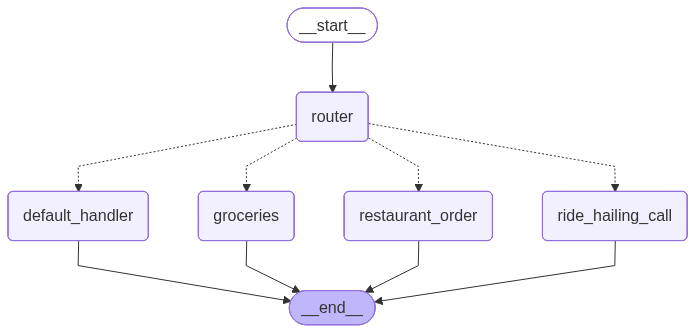

In [15]:
service_graph = StateGraph(ServiceRouterState)
service_graph.add_node("router", service_router_node)
service_graph.add_node("ride_hailing_call", ride_hailing_node)
service_graph.add_node("restaurant_order", restaurant_order_node)
service_graph.add_node("groceries", groceries_node)
service_graph.add_node("default_handler", default_handler_node)

service_graph.add_edge(START, "router")
service_graph.add_conditional_edges(
    "router",
    route_service,
    {
        "ride_hailing_call": "ride_hailing_call",
        "restaurant_order": "restaurant_order",
        "groceries": "groceries",
        "default_handler": "default_handler",
    },
)
service_graph.add_edge("ride_hailing_call", END)
service_graph.add_edge("restaurant_order", END)
service_graph.add_edge("groceries", END)
service_graph.add_edge("default_handler", END)

service_app = service_graph.compile()
show_graph(service_app)

In [16]:
test_cases = [
    "I need a ride from downtown to the airport at 3pm.",
    "I want to order 2 large pepperoni pizzas for delivery.",
    "I need milk, bread, eggs, and vegetables for the week.",
    "What's the weather like today?",
]

for user_input in test_cases:
    result = service_app.invoke({"user_input": user_input})
    print(f"Question: {user_input}")
    print(f"Route: {result['task_type']}")
    print(f"Output: {result['output']}")
    print("-" * 80)

Question: I need a ride from downtown to the airport at 3pm.
Route: ride_hailing_call
Output: {
  "pickup": "downtown",
  "destination": "the airport",
  "timing": "3pm",
  "ride_preferences": [],
  "special_requirements": []
}
--------------------------------------------------------------------------------
Question: I want to order 2 large pepperoni pizzas for delivery.
Route: restaurant_order
Output: {
  "items": [
    {
      "name": "pepperoni pizza",
      "quantity": 2,
      "size": "large"
    }
  ],
  "order_type": "delivery",
  "delivery_details": {
    "address": null
  },
  "missing_information": [
    "delivery address"
  ]
}
--------------------------------------------------------------------------------
Question: I need milk, bread, eggs, and vegetables for the week.
Route: groceries
Output: **Shopping List**
- Milk
- Bread
- Eggs
- Vegetables

**Missing quantities / preferences**
- **Milk:** quantity not specified; type not specified (e.g., whole, 2%, skim, oat, almond)

## Authors

Adapted from the original IBM Skills Network lab for current LangChain and LangGraph APIs.

Original authors:

<a href="https://author.skills.network/instructors/kunal_makwana" target="_blank">Kunal Makwana</a> is a passionate Data Scientist and AI enthusiast, currently working at IBM on innovative projects in Generative AI and machine learning. His journey began with a deep interest in mathematics and coding, which inspired him to explore how data can solve real-world problems. Over the years, he's gained hands-on experience in building scalable AI solutions, fine-tuning models, and leveraging cloud technologies to extract meaningful insights from complex datasets.

<a href="https://www.linkedin.com/in/joseph-s-50398b136/" target="_blank">Joseph Santarcangelo</a> has a  Ph.D. in Electrical Engineering with his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.
